# Rudimentary peak calling take 4

In [1]:
from pathlib import Path
import subprocess
from collections import defaultdict
from sys import float_info

import pandas as pd
from scipy import stats, optimize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm
from tqdm import tqdm

from dimelo import parse_bam
import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
# pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
pileup_id = "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/peak_calling/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [500, 1000, 1500, 2000, 5000, 10000]
step_sizes = window_sizes

# TODO: These really shouldn't be strings
mod_prob_thresholds = ["0.1", "0.5", "0.6", "0.65", "0.7", "0.75", "0.8", "0.9",]

p_threshold = 0.05

In [ ]:
# TODO: this won't work because the thresholds are going to be wrong; find a good solution

# ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"
# reference_file = config.raw_data_dir / "chm13v2.0.fa"
# motifs = ["A,0"]
# mod_prob_thresholds = np.linspace(0.1, 1, 10)
# # For now, chosing to export chr11 due to the presence of known CTCF features (β-globin, H19–Igf2)
# export_region = "chr11:0-135127769"
# n_cores = 10

# for mod_prob_threshold in mod_prob_thresholds:
#     output_name = f"pileup.{ctcf_bam_file.stem}.{mod_prob_threshold}"
#     parse_bam.pileup(
#         input_file=ctcf_bam_file,
#         output_name=output_name,
#         ref_genome=reference_file,
#         output_directory=output_dir,
#         regions=export_region,
#         motifs=motifs,
#         thresh=mod_prob_threshold,
#         cores=n_cores,
#         override_checks=True
#     )

## Generate windows

In [3]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    if not window_file.exists():
        subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

## Definitions

In [4]:
def modkit_stats(window_file: Path, mod_prob_threshold: str) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.{mod_prob_threshold}.tsv"
    pileup_file = output_dir / f"{pileup_id}.{mod_prob_threshold}" / "pileup.sorted.bed.gz"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]
    df["mod_frac"] = df["count_a"] / df["count_valid_a"]
    return df

In [5]:
def betabinom_loglikelihood(params,k,n) -> float:
    alpha, beta = params
    ll = stats.betabinom.logpmf(k,n,alpha,beta)
    return -ll.sum()

def fit_betabinom(k: pd.Series, n: pd.Series) -> tuple[float, float]:
    # from https://andrewpwheeler.com/2023/10/18/fitting-beta-binomial-in-python-poisson-scan-stat-in-r/
    # TODO: Nelder-Mead is the only one that has worked in testing; also what was referenced above. Is it always a good choice?
    result = optimize.minimize(betabinom_loglikelihood,[1,1],args=(k, n), method='Nelder-Mead')
    return tuple(result.x)

def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            # Fit a betabinomial
            alpha, beta = fit_betabinom(modkit_stats_df["count_a"], modkit_stats_df["count_valid_a"])
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "betabinom_beta":
            # Fit a beta
            # TODO: Is it correct to drop all of the invalid values this way? Could be adding pseudocounts. Could be pre-filtering. Does any of it matter?
            alpha, beta, *_ = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            probs = modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")
    
    # TODO: This is a hacky solution
    # Ensure there are no probabilities of 0
    return probs.replace(0, float_info.epsilon)

In [6]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    # TODO: This is a dangerous check; disable for final run
    if not label_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [7]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    if not window_chip_assignment_file.exists():
        # TODO: This is a dangerous check; disable for final run
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [ ]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    # TODO: come back and check that this is actually doing what I say it is. Is it counting peaks or peak regions?
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [ ]:
def roc_prc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[0].vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        axs[0].hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        axs[0].set_title(f"ROC: p<{threshold}")
    else:
        axs[0].set_title("ROC")
    axs[0].legend(loc="lower right")
    axs[0].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[1].vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        axs[1].hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        axs[1].set_title(f"precision-recall curve: p<{threshold}")
    else:
        axs[1].set_title("precision-recall curve")
    axs[1].legend(loc="best")
    axs[1].set_xlabel("recall")
    axs[1].set_ylabel("precision")
    axs[1].set_box_aspect(1)

    plt.show()
    plt.close()

In [ ]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [11]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    axs[1].set_box_aspect(1)
   
    plt.show()
    plt.close()

## Test different fitting methods

In [24]:
modkit_stats_df = modkit_stats(window_files[2], "0.9")

In [25]:
def bbll(parms,k,n):
    alpha, beta = parms
    ll = stats.betabinom.logpmf(k,n,alpha,beta)
    return -ll.sum()

result = optimize.minimize(bbll,[1,1],args=(modkit_stats_df["count_a"], modkit_stats_df["count_valid_a"]), method='Nelder-Mead')
bb_params = result.x

In [26]:
bbb_params = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)

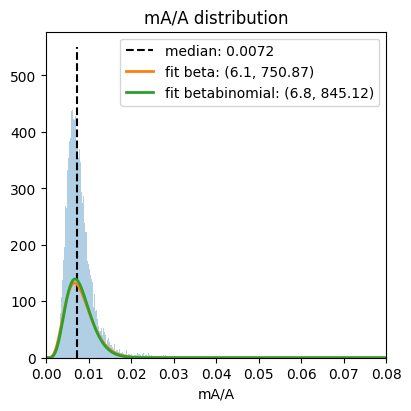

In [29]:
plt.figure(figsize=(4,4), layout="constrained")
modkit_stats_df["mod_frac"].hist(bins=5000, alpha=0.35)
# modkit_stats_df["mod_frac"].plot.kde(color="tab:red", lw=2)
plt.vlines(modkit_stats_df["mod_frac"].median(), 0, 550, label=f'median: {modkit_stats_df["mod_frac"].median():.2}', color="black", linestyle="--")
x = np.linspace(0, 0.08, 500)
for params, label in zip((bbb_params, bb_params), ("fit beta", "fit betabinomial")):
    plt.plot(x, stats.beta.pdf(x, *params), label=f"{label}: ({float(params[0]):.2}, {float(params[1]):.5})", lw=2)
# plt.plot(x, stats.beta.pdf(x, *bbbh_params), color="tab:green", label='hand-fit beta pdf', lw=2)
# plt.plot(x, stats.beta.pdf(x, *bbb_params), color="tab:red", label='fit beta pdf', lw=2)
# plt.plot(x, stats.beta.pdf(x, *bb_params), color="tab:blue", label='fit betabinomial beta pdf', lw=2)
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

## Running analysis

In [12]:
threshold_result_dfs = defaultdict(list)
for mod_prob_threshold in tqdm(mod_prob_thresholds):
    for window_file in tqdm(window_files):
        modkit_stats_df = modkit_stats(window_file, mod_prob_threshold)
        # TODO: don't like reliance on column names
        modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, "betabinom")
        label_df = window_labels(window_file, ctcf_chip_seq_file)
        window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
        labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
        threshold_result_dfs[mod_prob_threshold].append(labeled_stats_df)

  0%|          | 0/8 [00:00<?, ?it/s]> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
 12%|█▎        | 1/8 [00:55<06:26, 55.22s/it]> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
 25%|██▌       | 2/8 [01:50<05:32, 55.44s/it]> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
 50%|█████     | 4/8 [13:41<19:28, 292.17s/it]> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (

## Plotting

In [ ]:
# for distribution in ["betabinom"]:
#     for window_size, labeled_stats_df in zip(window_sizes, distribution_result_dfs[distribution]):
#         print(distribution, window_size)
#         roc_prc_plot(labeled_stats_df, threshold=p_threshold)
#         confusion_matrix_plot(labeled_stats_df, threshold=p_threshold)
#         peak_label_plots(labeled_stats_df, threshold=p_threshold)

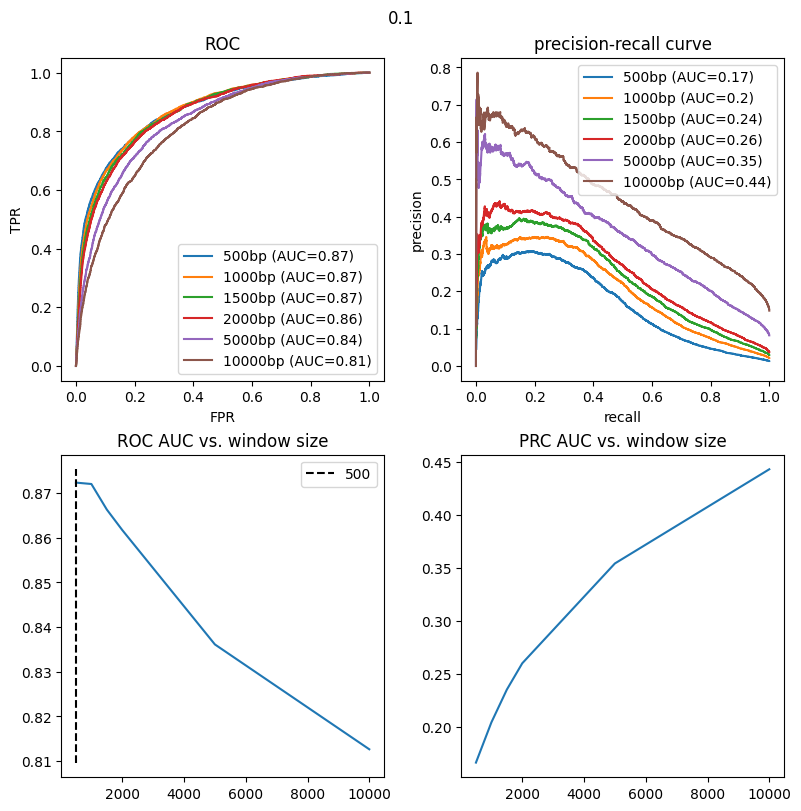

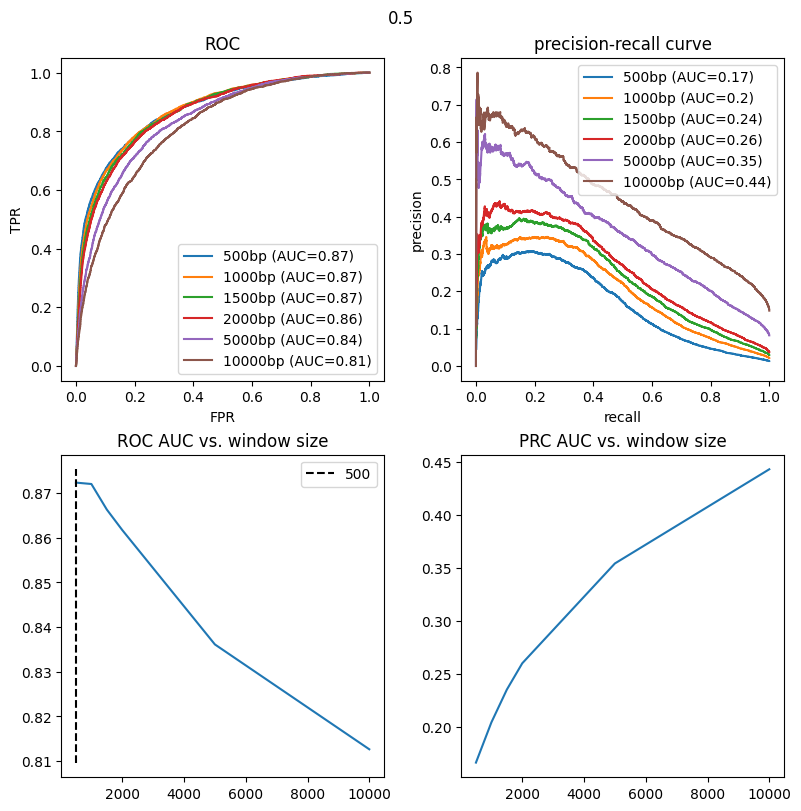

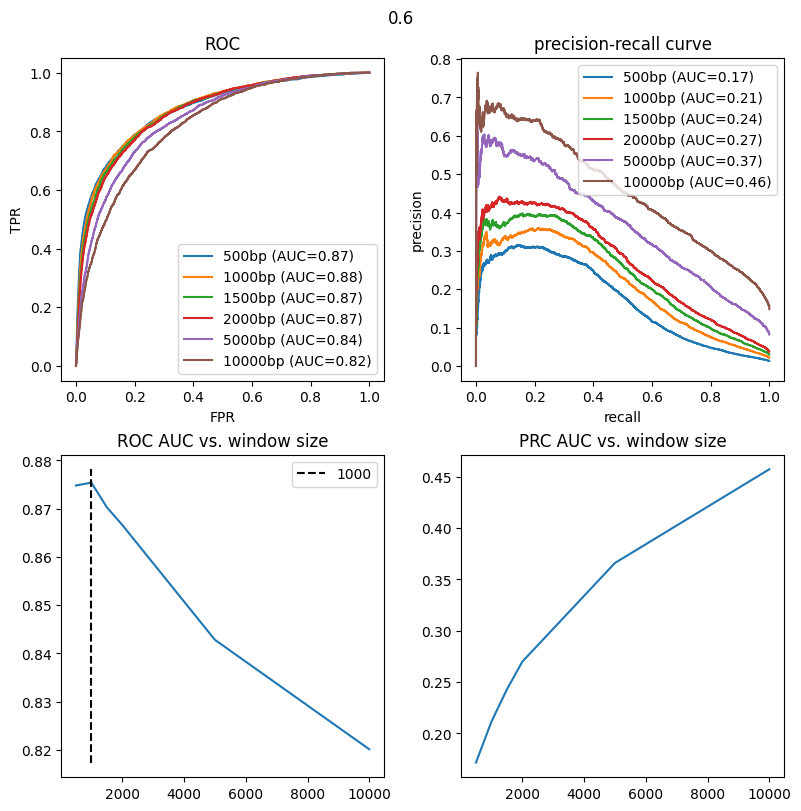

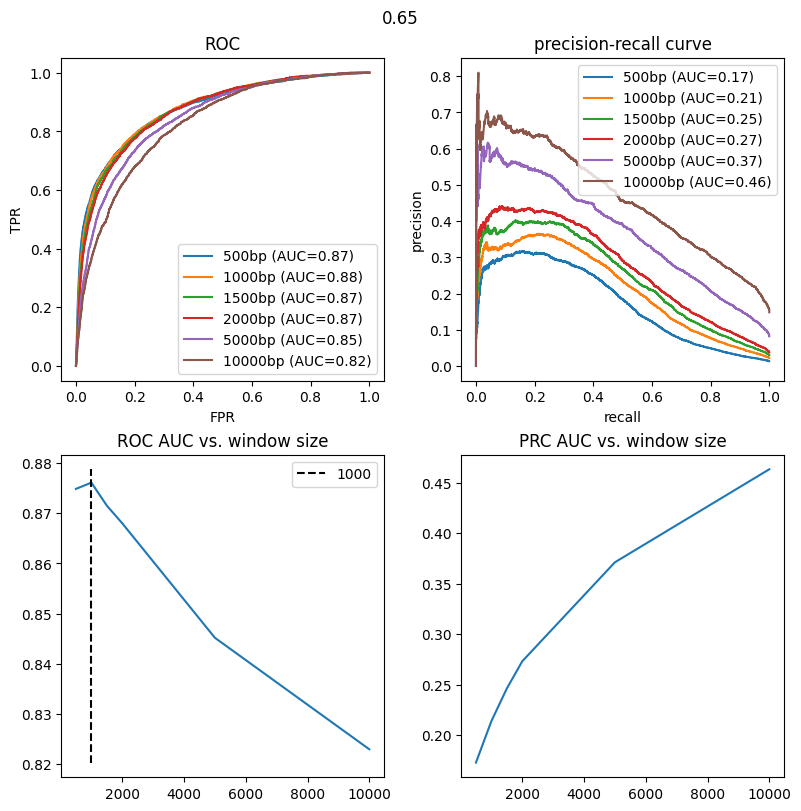

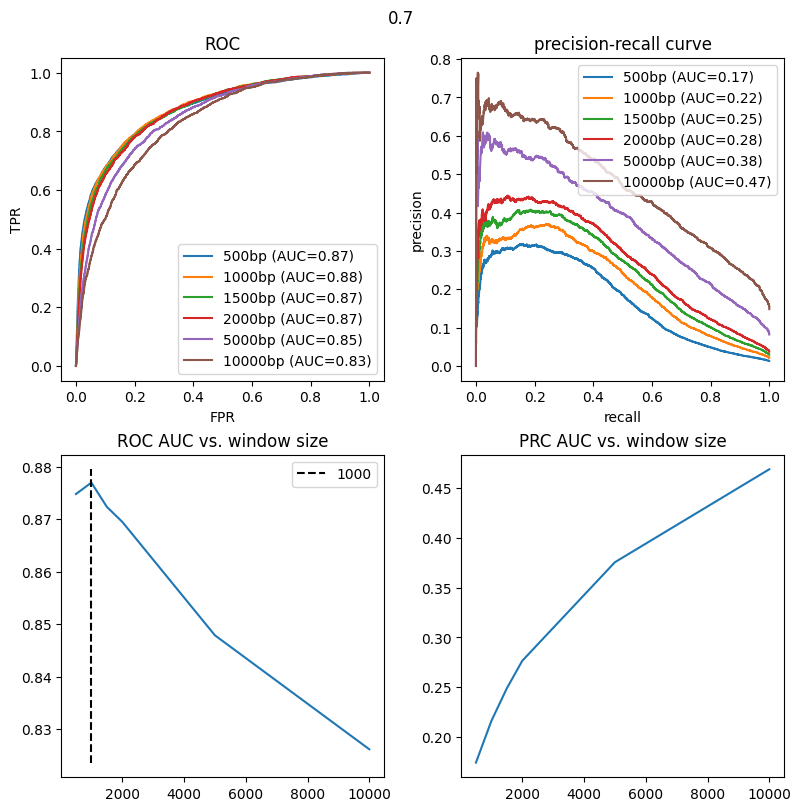

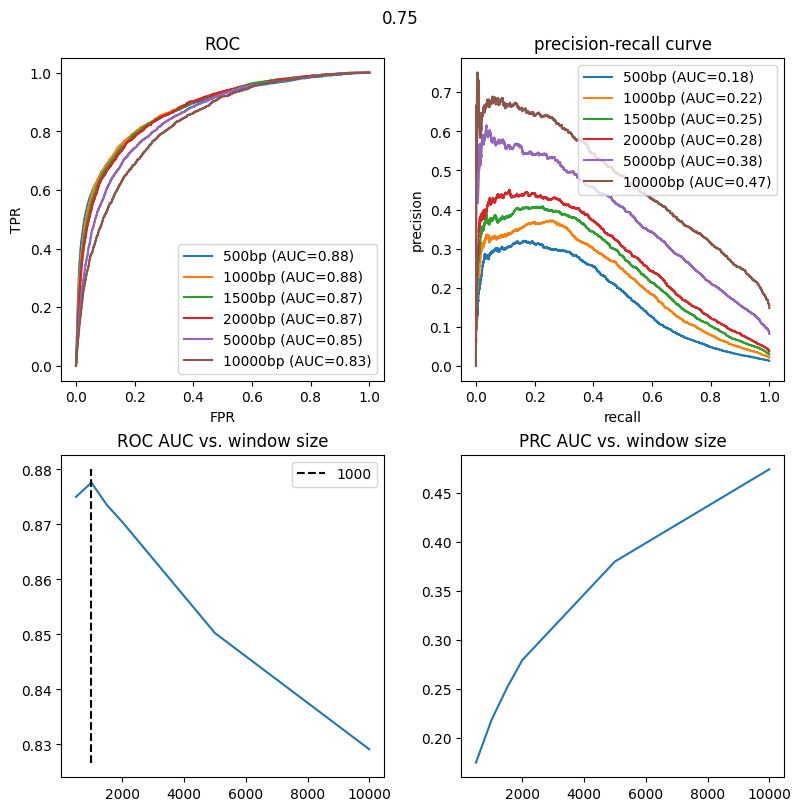

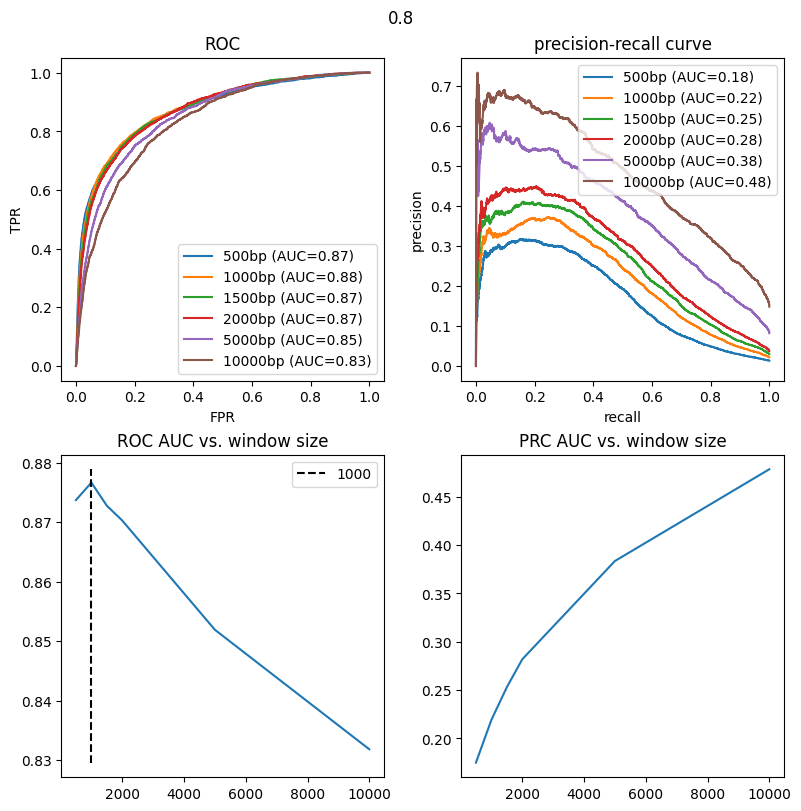

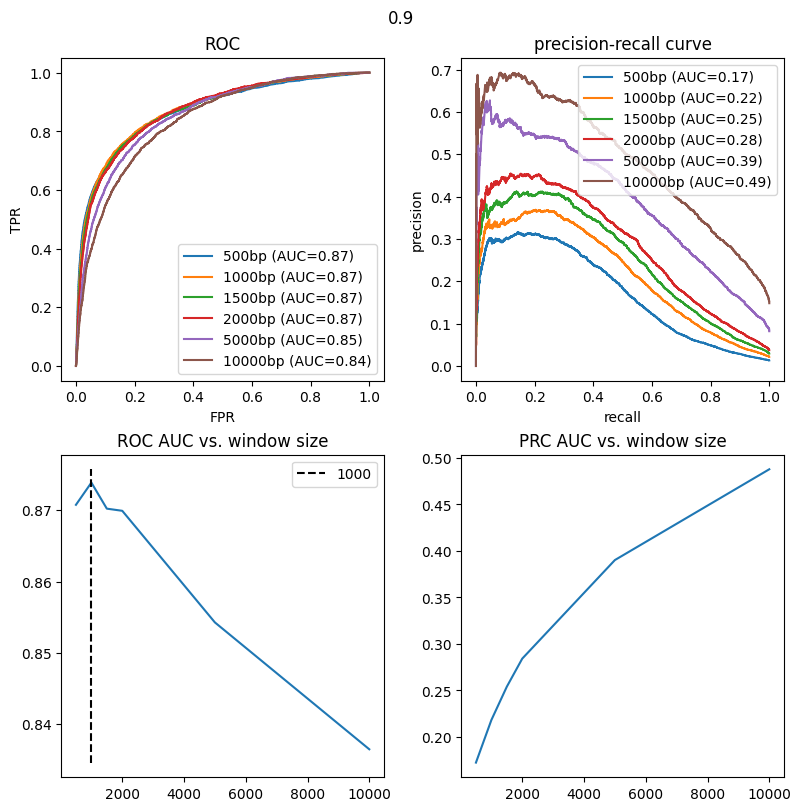

In [13]:
for mod_prob_threshold in mod_prob_thresholds:
    _, axs = plt.subplots(2, 2, layout="constrained", figsize=(8, 8))
    roc_aucs = []
    prc_aucs = []
    for window_size, labeled_stats_df in zip(window_sizes, threshold_result_dfs[mod_prob_threshold]):
        roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
        prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])
        roc_aucs.append(roc_auc)
        prc_aucs.append(prc_auc)

        axs[0][0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"{window_size}bp (AUC={roc_auc:.2})")

        axs[0][1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"{window_size}bp (AUC={prc_auc:.2})")
        # baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
        # axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    axs[1][0].plot(window_sizes, roc_aucs)
    y_min, y_max = axs[1][0].get_ylim()
    roc_auc_max_window = window_sizes[roc_aucs.index(max(roc_aucs))]
    axs[1][0].vlines(x=roc_auc_max_window, ymin=y_min, ymax=y_max, color="black", linestyle="--", label=f"{roc_auc_max_window}")

    axs[1][1].plot(window_sizes, prc_aucs)

    axs[0][0].set_title("ROC")
    axs[0][0].legend(loc="lower right")
    axs[0][0].set_xlabel("FPR")
    axs[0][0].set_ylabel("TPR")
    axs[0][0].set_box_aspect(1)

    axs[0][1].set_title("precision-recall curve")
    axs[0][1].legend(loc="best")
    axs[0][1].set_xlabel("recall")
    axs[0][1].set_ylabel("precision")
    axs[0][1].set_box_aspect(1)

    axs[1][0].set_title("ROC AUC vs. window size")
    axs[1][0].legend()
    axs[1][0].set_box_aspect(1)

    axs[1][1].set_title("PRC AUC vs. window size")
    axs[1][1].set_box_aspect(1)

    plt.suptitle(mod_prob_threshold)

    plt.show()
    plt.close()

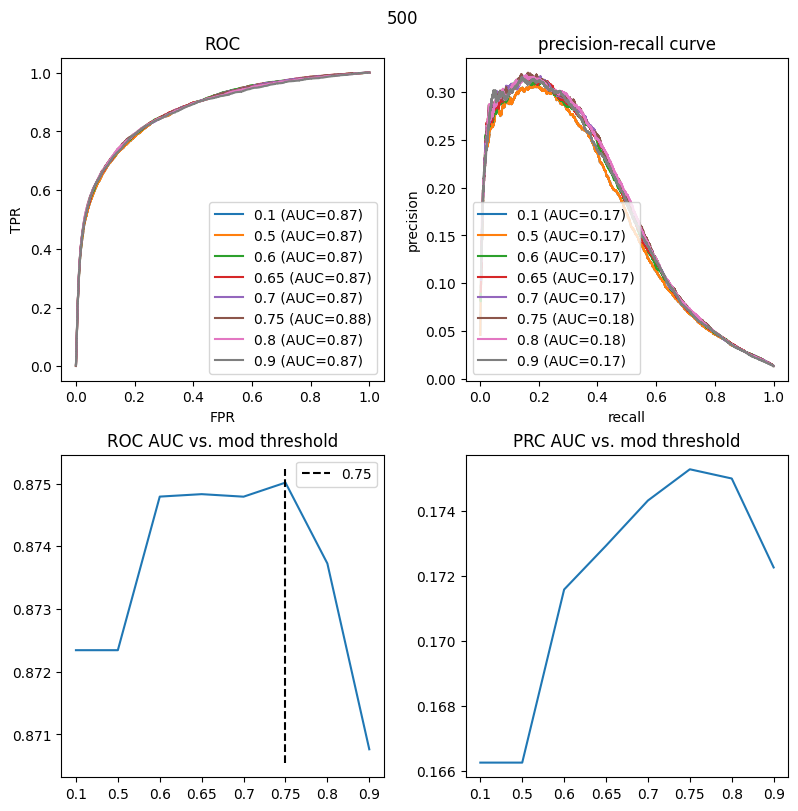

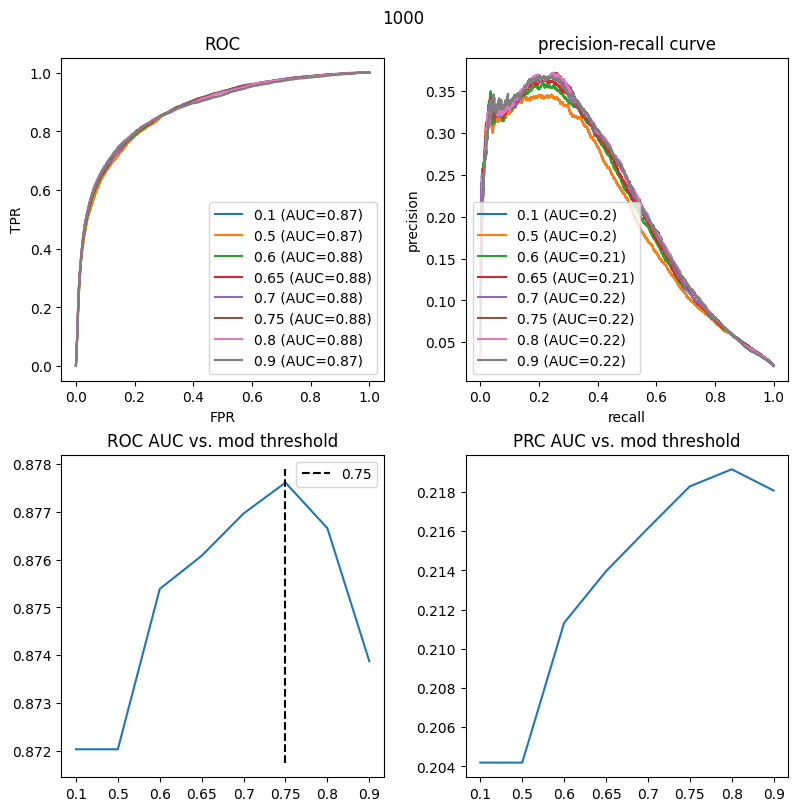

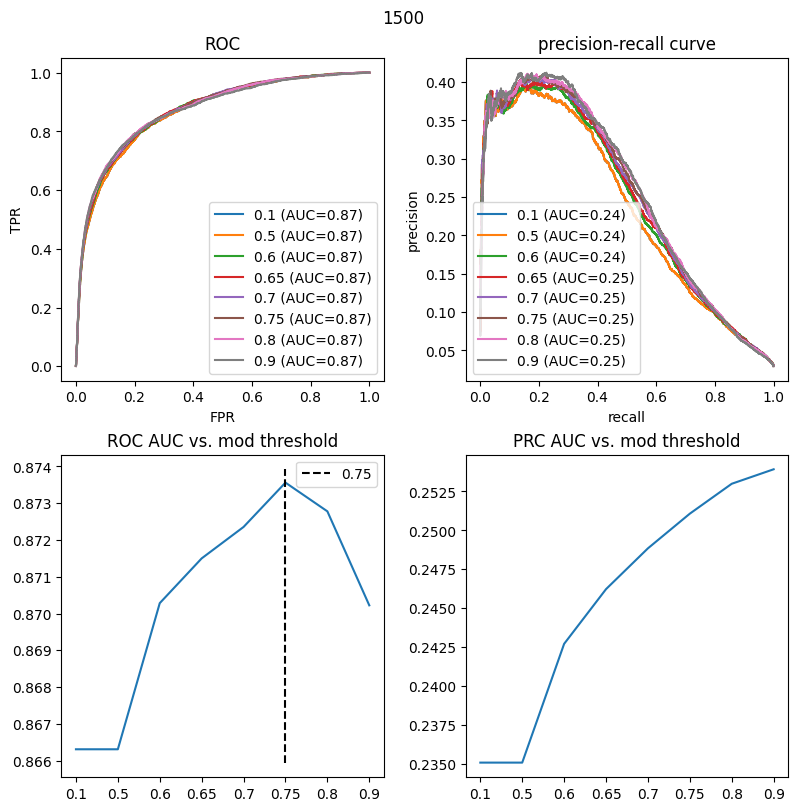

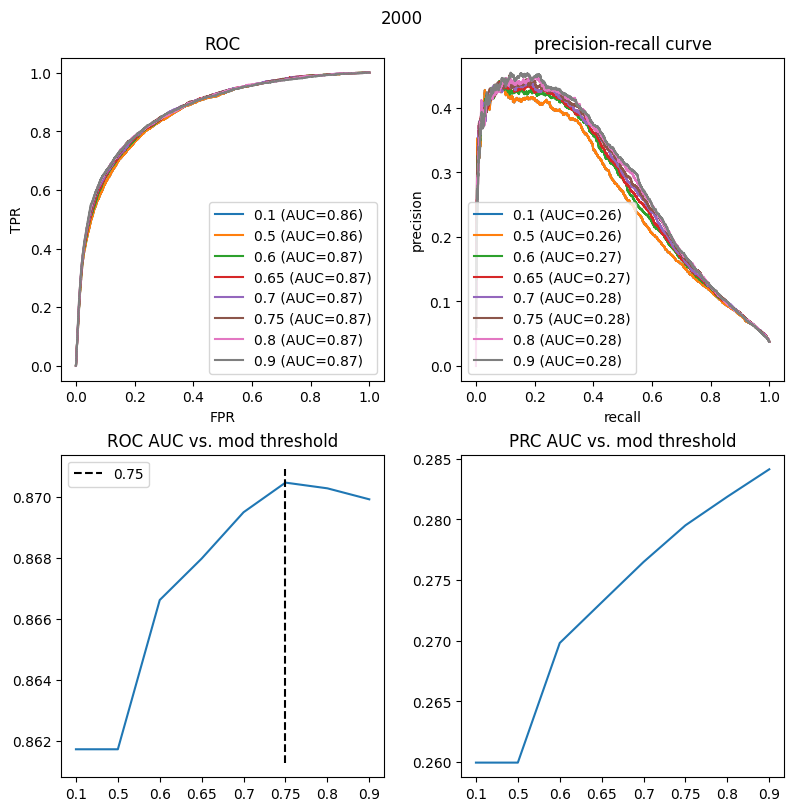

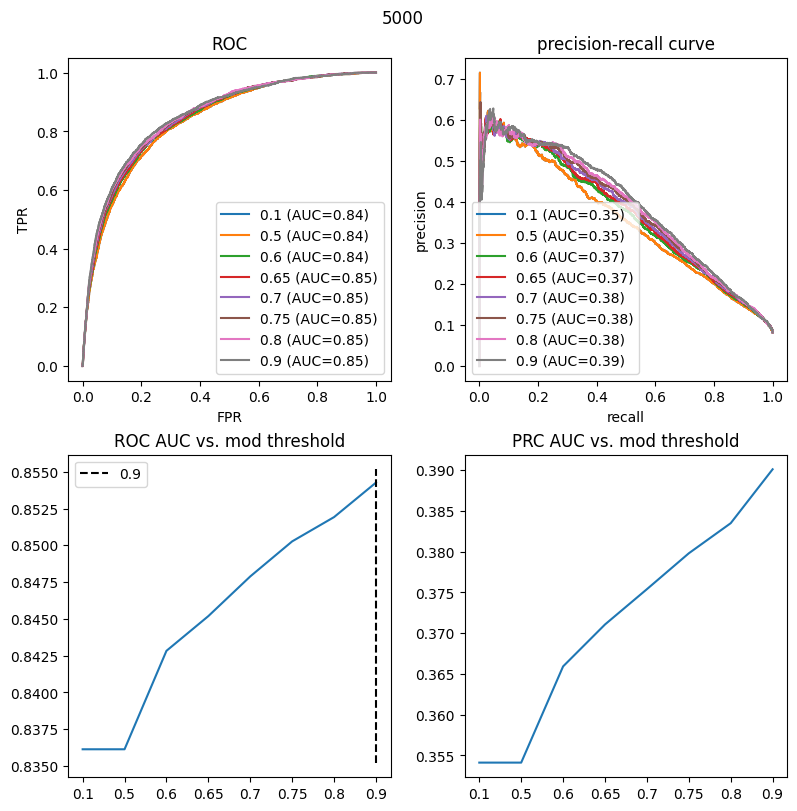

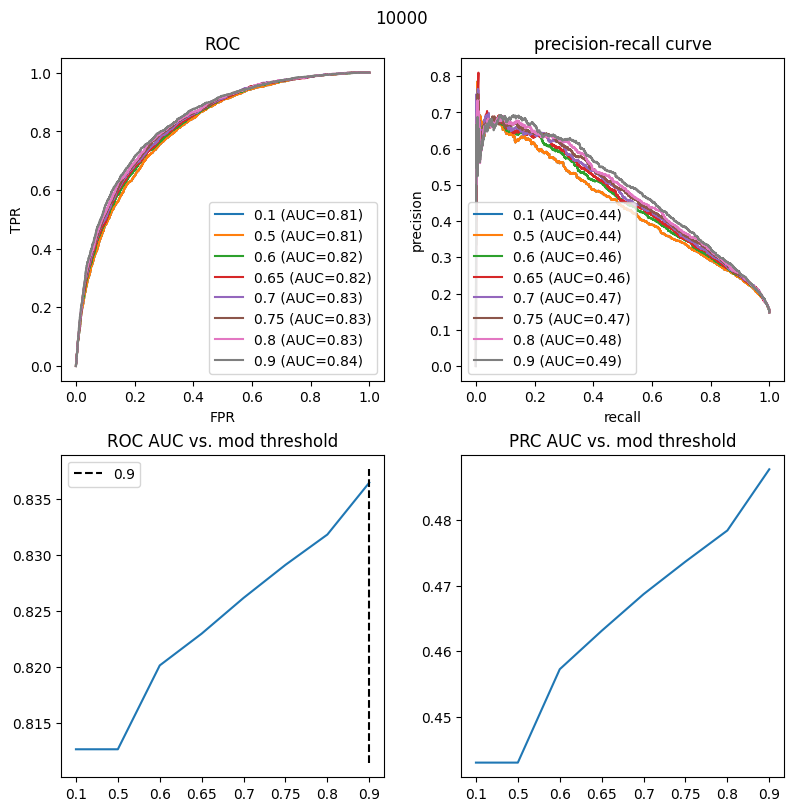

In [103]:
for i, window_size in enumerate(window_sizes):
    _, axs = plt.subplots(2, 2, layout="constrained", figsize=(8, 8))
    roc_aucs = []
    prc_aucs = []
    for mod_prob_threshold in mod_prob_thresholds:
        labeled_stats_df = threshold_result_dfs[mod_prob_threshold][i]
        roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
        prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])
        roc_aucs.append(roc_auc)
        prc_aucs.append(prc_auc)

        axs[0][0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"{mod_prob_threshold} (AUC={roc_auc:.2})")

        axs[0][1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"{mod_prob_threshold} (AUC={prc_auc:.2})")
        # baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
        # axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    axs[1][0].plot(mod_prob_thresholds, roc_aucs)
    y_min, y_max = axs[1][0].get_ylim()
    roc_auc_max_window = mod_prob_thresholds[roc_aucs.index(max(roc_aucs))]
    axs[1][0].vlines(x=roc_auc_max_window, ymin=y_min, ymax=y_max, color="black", linestyle="--", label=f"{roc_auc_max_window}")

    axs[1][1].plot(mod_prob_thresholds, prc_aucs)

    axs[0][0].set_title("ROC")
    axs[0][0].legend(loc="lower right")
    axs[0][0].set_xlabel("FPR")
    axs[0][0].set_ylabel("TPR")
    axs[0][0].set_box_aspect(1)

    axs[0][1].set_title("precision-recall curve")
    axs[0][1].legend(loc="best")
    axs[0][1].set_xlabel("recall")
    axs[0][1].set_ylabel("precision")
    axs[0][1].set_box_aspect(1)

    axs[1][0].set_title("ROC AUC vs. mod threshold")
    axs[1][0].legend()
    axs[1][0].set_box_aspect(1)

    axs[1][1].set_title("PRC AUC vs. mod threshold")
    axs[1][1].set_box_aspect(1)

    plt.suptitle(str(window_size))

    plt.show()
    plt.close()

In [128]:
x_vals = []
y_vals = []
vals = []
for i, window_size in enumerate(window_sizes):
    for mod_prob_threshold in mod_prob_thresholds:
        x_vals.append(mod_prob_threshold)
        y_vals.append(window_size)
        labeled_stats_df = threshold_result_dfs[mod_prob_threshold][i]
        vals.append(np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"]))
x_label = "modification probability threshold"
y_label = "window size"
vals_label = "ROC AUC"
sns.heatmap(pd.DataFrame({x_label: x_vals, y_label: y_vals, vals_label: vals}).pivot(index=y_label, columns=x_label, values=vals_label), cmap="mako", cbar_kws={"label": vals_label})
# plt.show()
plt.savefig("ROC_AUC_heatmap.svg")
plt.close()

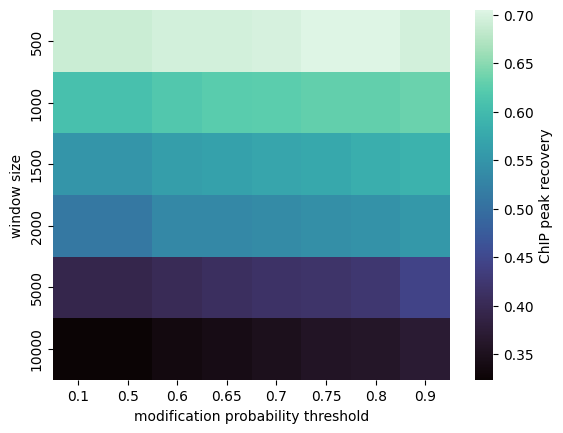

In [102]:
x_vals = []
y_vals = []
vals = []
for i, window_size in enumerate(window_sizes):
    for mod_prob_threshold in mod_prob_thresholds:
        x_vals.append(mod_prob_threshold)
        y_vals.append(window_size)
        labeled_stats_df = threshold_result_dfs[mod_prob_threshold][i]
        vals.append(labeled_stats_df.query(f"prob < 0.05").iloc[-1]["ChIP Recovery Fraction"])
x_label = "modification probability threshold"
y_label = "window size"
vals_label = "ChIP peak recovery"
sns.heatmap(pd.DataFrame({x_label: x_vals, y_label: y_vals, vals_label: vals}).pivot(index=y_label, columns=x_label, values=vals_label), cmap="mako", cbar_kws={"label": vals_label})
plt.show()
plt.close()

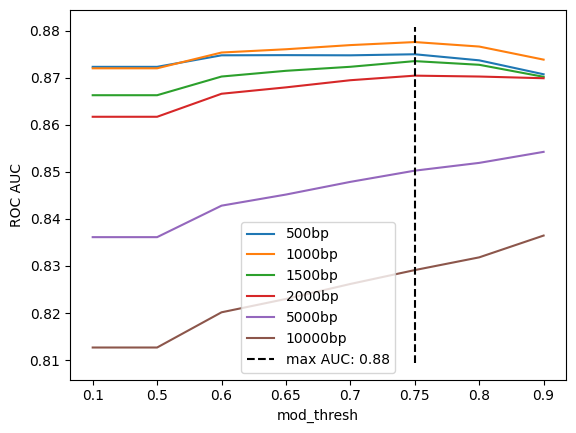

In [15]:
max_auc = 0
max_auc_thresh = 0
for i, window_size in enumerate(window_sizes):
    roc_aucs = [np.trapezoid(threshold_result_dfs[thresh][i]["TPR"], threshold_result_dfs[thresh][i]["FPR"]) for thresh in mod_prob_thresholds]
    plt.plot(mod_prob_thresholds, roc_aucs, label=f"{window_size}bp")
    window_max_auc = max(roc_aucs)
    if window_max_auc > max_auc:
        max_auc = window_max_auc
        max_auc_thresh = mod_prob_thresholds[roc_aucs.index(window_max_auc)]
y_min, y_max = plt.ylim()
plt.vlines(x=max_auc_thresh, ymin=y_min, ymax=y_max, color="k", linestyle="--", label=f"max AUC: {max_auc:.2}")

plt.xlabel("mod_thresh")
plt.ylabel("ROC AUC")
plt.legend()
plt.show()
plt.close()

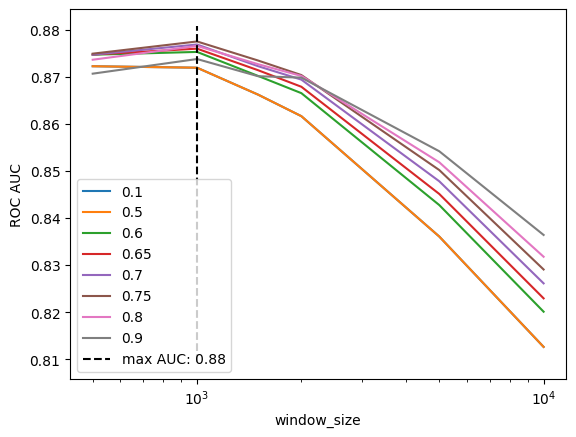

In [16]:
max_auc = 0
max_auc_window_size = 0
for thresh in mod_prob_thresholds:
    roc_aucs = [np.trapezoid(threshold_result_dfs[thresh][i]["TPR"], threshold_result_dfs[thresh][i]["FPR"]) for i, _ in enumerate(window_sizes)]
    plt.plot(window_sizes, roc_aucs, label=f"{thresh}")
    thresh_max_auc = max(roc_aucs)
    if thresh_max_auc > max_auc:
        max_auc = thresh_max_auc
        max_auc_window_size = window_sizes[roc_aucs.index(thresh_max_auc)]
y_min, y_max = plt.ylim()
plt.vlines(x=max_auc_window_size, ymin=y_min, ymax=y_max, color="k", linestyle="--", label=f"max AUC: {max_auc:.2}")

plt.xlabel("window_size")
plt.ylabel("ROC AUC")
plt.semilogx()
plt.legend()
plt.show()
plt.close()

In [137]:
window_size = 1000
window_size_idx = window_sizes.index(window_size)
thresh = "0.5"
print(window_size, thresh)

labeled_stats_df = threshold_result_dfs[thresh][window_size_idx]
threshold = p_threshold

roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
_, ax = plt.subplots()
plt.plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
if threshold is not None:
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    plt.vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
    plt.hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
    plt.title(f"ROC: p<{threshold}")
else:
    plt.title("ROC")
plt.legend(loc="lower right")
plt.xlabel("FPR")
plt.ylabel("TPR")
ax.set_box_aspect(1)
plt.savefig("peak_calling_ROC.svg")
plt.close()

prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])
_, ax = plt.subplots()
plt.plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
plt.hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")
if threshold is not None:
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    plt.vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
    plt.hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
    plt.title(f"precision-recall curve: p<{threshold}")
else:
    plt.title("precision-recall curve")
plt.legend(loc="best")
plt.xlabel("recall")
plt.ylabel("precision")
ax.set_box_aspect(1)
plt.savefig("peak_calling_PRC.svg")
plt.close()

_, ax = plt.subplots()
plt.plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
plt.xlabel("p threshold")
plt.ylabel("fraction of ChIP peaks recovered")
plt.title("ChIP peak recovery as a function of threshold")
if threshold is not None:
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    threshold_n_hits = threshold_row.name

    plt.vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
    plt.legend(loc="lower right")
ax.set_box_aspect(1)
plt.savefig("peak_calling_recovery.svg")
plt.close()

# peak_label_plots(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)

1000 0.5


1000 0.5


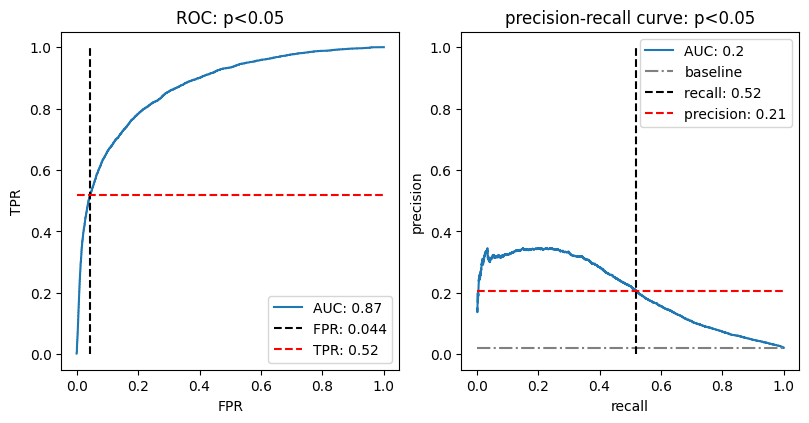

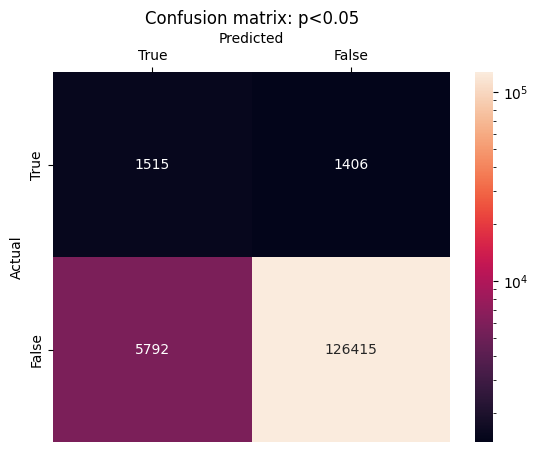

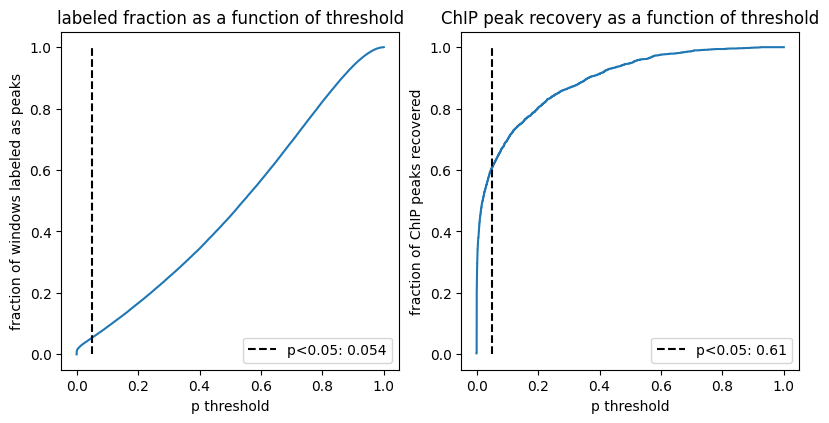

In [100]:
window_size = 1000
window_size_idx = window_sizes.index(window_size)
thresh = "0.5"
print(window_size, thresh)
roc_prc_plot(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)
confusion_matrix_plot(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)
peak_label_plots(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)

1000 0.75


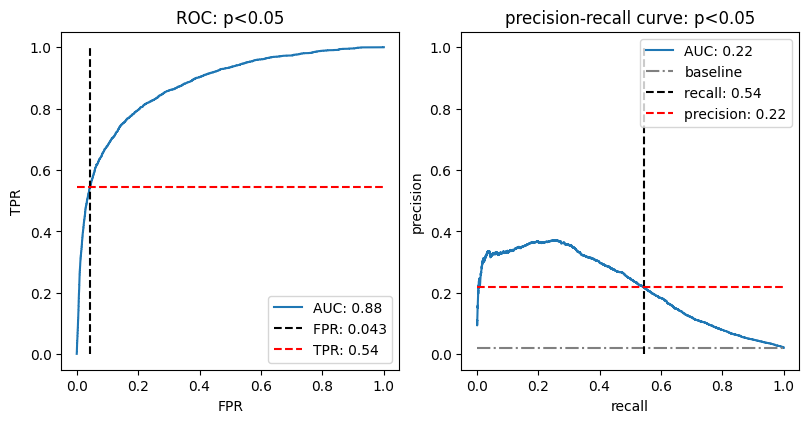

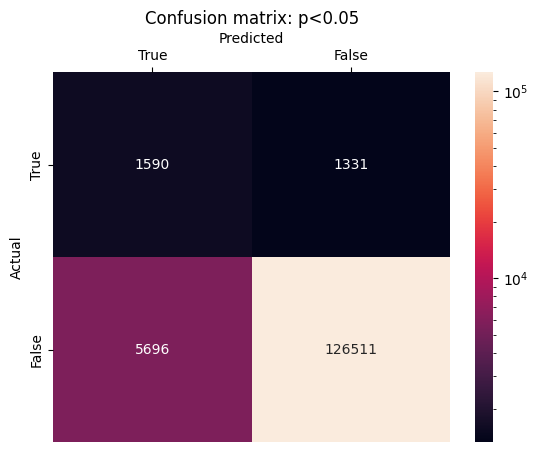

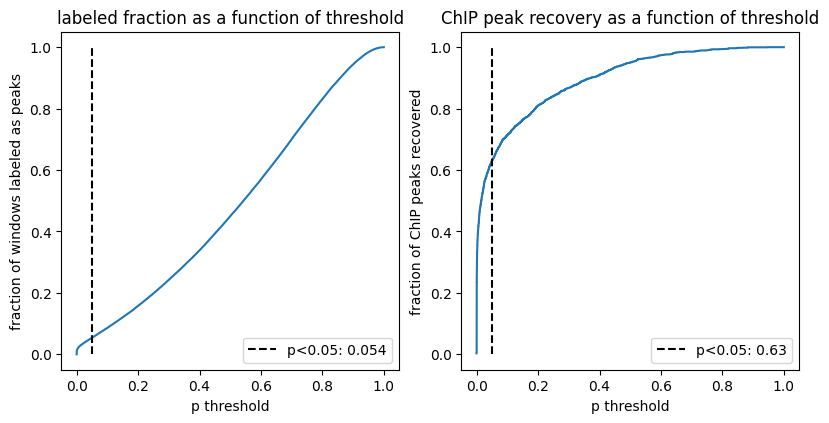

In [101]:
window_size = 1000
window_size_idx = window_sizes.index(window_size)
thresh = "0.75"
print(window_size, thresh)
roc_prc_plot(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)
confusion_matrix_plot(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)
peak_label_plots(threshold_result_dfs[thresh][window_size_idx], threshold=p_threshold)

In [112]:
test = threshold_result_dfs["0.75"][window_sizes.index(1000)]

In [114]:
FDR_thresh = 0.05
test["prob"] < (test.index + 1) / len(test) * FDR_thresh

0          True
1          True
2          True
3          True
4          True
          ...  
135123    False
135124    False
135125    False
135126    False
135127    False
Length: 135128, dtype: bool

1000 0.75


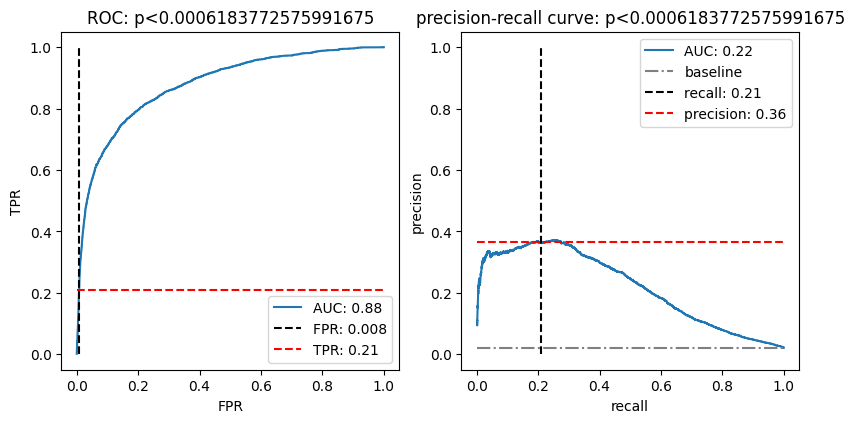

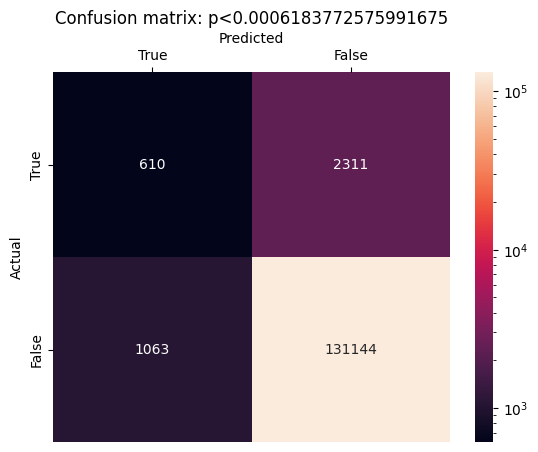

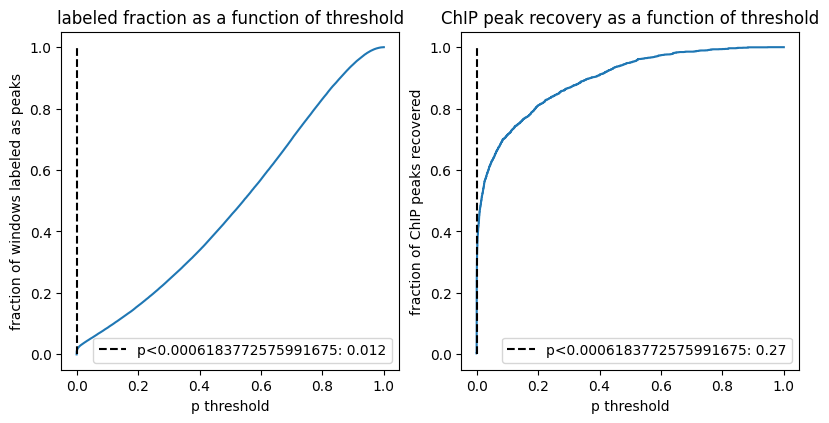

In [117]:
FDR_p_thresh = test[test["prob"] < (test.index + 1) / len(test) * FDR_thresh].iloc[-1]["prob"]

window_size = 1000
window_size_idx = window_sizes.index(window_size)
thresh = "0.75"
print(window_size, thresh)
roc_prc_plot(threshold_result_dfs[thresh][window_size_idx], threshold=FDR_p_thresh)
confusion_matrix_plot(threshold_result_dfs[thresh][window_size_idx], threshold=FDR_p_thresh)
peak_label_plots(threshold_result_dfs[thresh][window_size_idx], threshold=FDR_p_thresh)

1000 0.75


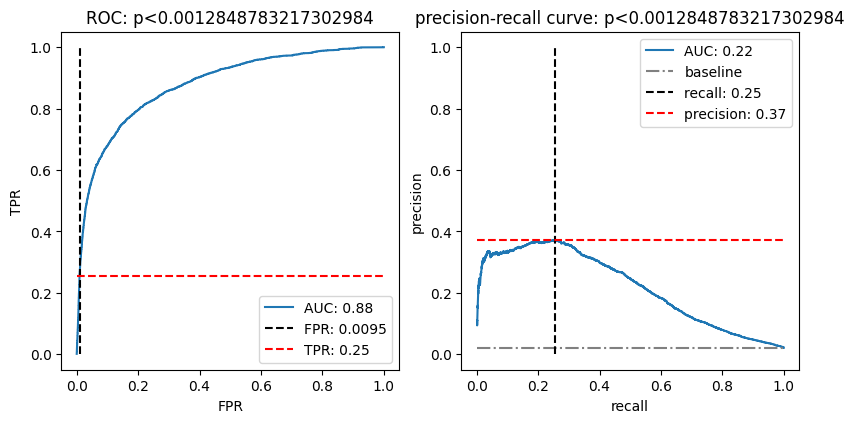

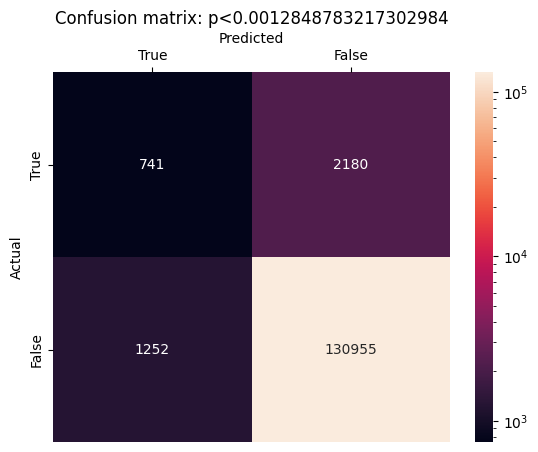

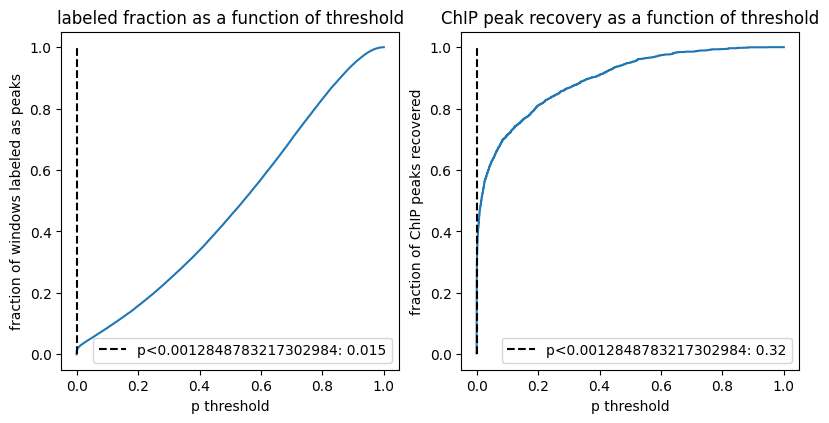

In [120]:
max_precision_p_thresh = test.iloc[test["precision"].idxmax()]["prob"]

window_size = 1000
window_size_idx = window_sizes.index(window_size)
thresh = "0.75"
print(window_size, thresh)
roc_prc_plot(threshold_result_dfs[thresh][window_size_idx], threshold=max_precision_p_thresh)
confusion_matrix_plot(threshold_result_dfs[thresh][window_size_idx], threshold=max_precision_p_thresh)
peak_label_plots(threshold_result_dfs[thresh][window_size_idx], threshold=max_precision_p_thresh)

# Single read analysis

In [1]:
from pathlib import Path
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from dimelo import parse_bam, load_processed
import config, utils

import memray
import cProfile
import pstats

In [76]:
ctcf_chip_peak_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.bed"
genome_index_file = config.raw_data_dir / "chm13v2.0.fa.fai"
genome_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"

output_dir = config.working_dir / "review_data" / "single_read"
ctcf_chip_peak_centers_file = output_dir / ctcf_chip_peak_file.with_suffix(".centers.bed").name
ctcf_peak_regions_file =  output_dir / ctcf_chip_peak_file.with_suffix(".regions.bed").name

ctcf_output_id = f"{ctcf_bam_file.stem}.{ctcf_peak_regions_file.stem}"
# 400 / 2
window_size = 200
motifs = ["A,0", "WCG,1", "GCH,1"]
n_cores = 10
thresh = 0.95

In [3]:
# TODO: Use this in the third party data notebook; way quicker
subprocess.run(f"awk -F '\t' 'BEGIN {{OFS=FS}} {{midpoint = int(($3 + $2) / 2); $2 = midpoint; $3 = midpoint + 1; print}}' {ctcf_chip_peak_file} > {ctcf_chip_peak_centers_file}", shell=True)
subprocess.run(f"bedtools slop -i {ctcf_chip_peak_centers_file} -g {genome_index_file} -b {window_size}  > {ctcf_peak_regions_file}", shell=True)

CompletedProcess(args='bedtools slop -i /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.centers.bed -g /Users/jeremy/devspace/multimodal-dimelo/data/raw/chm13v2.0.fa.fai -b 200  > /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.bed', returncode=0)

In [ ]:
parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}",
    ref_genome=genome_file,
    output_directory=output_dir,
    regions=ctcf_peak_regions_file,
    motifs=motifs,
    thresh=None, # TODO: No thresholding at extract time?
    cores=n_cores,
    override_checks=True,
)

awk '$1 == "chr1"' /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.chr1.bed > /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.chr1.bed


In [77]:
# Temporarily just look at one chromosome for speed and memory
target_chrom = "chr11"
target_file = output_dir / ctcf_chip_peak_file.with_suffix(".regions.chrX.bed").name
subprocess.run(f"awk '$1 == \"{target_chrom}\"' {ctcf_peak_regions_file} > {target_file}", shell=True)
ctcf_peak_regions_file = target_file

In [78]:
regions_df = utils.load_encode_narrowpeak_bed(ctcf_peak_regions_file)
regions_df["window_spec"] = regions_df["chrom"] + ":" + regions_df["chromStart"].astype("str") + "-" + regions_df["chromEnd"].astype("str")

<Axes: >

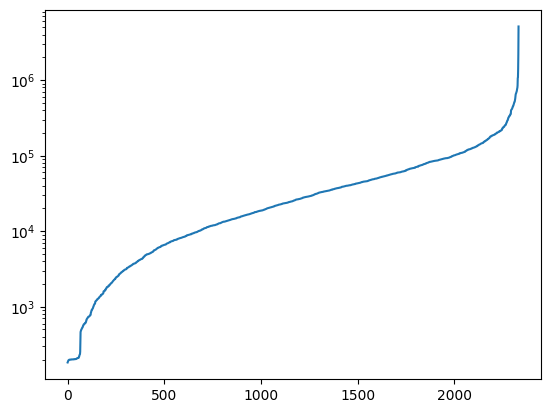

In [79]:
regions_df["chromStart"].sort_values().diff().sort_values(ignore_index=True).plot(logy=True)

In [47]:
def generate_streak_info(results: pd.Series):
    """
    https://joshdevlin.com/blog/calculate-streaks-in-pandas/
    """
    streak_ids = results.ne(results.shift()).cumsum()
    streak_counter = streak_ids.groupby(streak_ids).cumcount() + 1
    return streak_counter

In [54]:
regions_df["chromEnd"] - regions_df["chromStart"]

0       401
1       401
2       401
3       401
4       401
       ... 
2330    401
2331    401
2332    401
2333    401
2334    401
Length: 2335, dtype: int64

In [62]:
seq = regions_df["chromStart"].sort_values(ignore_index=True).diff() < 79674
streak_counter = generate_streak_info(seq)
pd.concat([seq, streak_counter], axis="columns")

,chromStart,0
0,False,1
1,True,1
2,True,2
3,True,3
4,True,4
...,...,...
2330,False,1
2331,False,2
2332,False,3
2333,True,1


In [63]:
streak_counter[seq].max()

np.int64(66)

In [80]:
sorted_read_data_converted, datasets, regions_dict = load_processed.read_vectors_from_hdf5(
    file=output_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
    motifs=motifs,
    regions=ctcf_peak_regions_file,
    window_size=None,
    calculate_mod_fractions=False,
    span_full_window=True
)

In [6]:
from collections import Counter

In [7]:
for k, v in Counter(Counter([read_tuple[datasets.index("read_name")] for read_tuple in sorted_read_data_converted]).values()).items():
    print(f"{k:>2}: {v}")

 3: 33401
12: 534
 9: 1739
 6: 6955
 2: 6412
 1: 22
 4: 281
 5: 25
11: 3
15: 123
18: 73
 8: 10
21: 30
27: 4
36: 1
24: 5
33: 1
39: 1
 7: 3
30: 1
14: 1


In [8]:
Counter([read_tuple[datasets.index("read_name")] for read_tuple in sorted_read_data_converted])

Counter({'dfe2b30b-bd7d-4b0f-8103-f92483032955': 39,
         '5eeed69f-aaca-4bd8-a37f-b6fc899c0a7e': 36,
         'b5f960fb-585c-4086-8e98-05115a044e85': 33,
         '1c882b1f-72b3-4ef1-aa15-5d43dd3e5797': 30,
         'b4f91546-68b3-48e5-a12f-3f60c8eb4d4f': 27,
         'c71a94c5-621b-40ee-811a-9da31e0f8c46': 27,
         'a09c184f-98df-4464-b552-90c6e174f968': 27,
         '93821a59-9b28-4e75-9873-0a932b82dbe4': 27,
         '57ca2932-52b0-4bc8-a5c5-353f870f62b5': 24,
         '5ebdd43f-348e-4e21-85b5-4f239eecda6a': 24,
         'a50eed0d-901e-4fa0-a7c3-0cba458f9e10': 24,
         '71702614-ef72-4a06-9fe7-790c8cef800d': 24,
         '01670791-c0e2-4b60-8694-fdc07c63ab0c': 24,
         'a6f299e2-31c1-4d13-995d-e577e138c581': 21,
         '5c447c98-32d0-4613-962c-662def158946': 21,
         '64ae0e43-9d3f-4deb-b951-0925ac80a778': 21,
         '8fca4043-afcd-43df-bab4-80efdfc04bd0': 21,
         '69597b49-6b95-43de-a2f2-01c108fd502a': 21,
         '9837be1b-38c7-4cfb-882a-0f45dcae87b0

In [9]:
test = [x for x in sorted_read_data_converted if x[datasets.index("read_name")] == "dfe2b30b-bd7d-4b0f-8103-f92483032955"]

In [10]:
[(x[datasets.index("motif")], len(x[datasets.index("mod_vector")])) for x in test]

[('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894),
 ('A,0', 76117),
 ('GCH,1', 76122),
 ('WCG,1', 75894)]

In [11]:
[(x[datasets.index("motif")], x[datasets.index("read_start")], x[datasets.index("read_end")]) for x in test]

[('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(64274307), np.int32(64353981)),
 ('WCG,1', np.int32(64274315), np.int32(64353976)),
 ('A,0', np.int32(64274307), np.int32(64353981)),
 ('GCH,1', np.int32(642743

In [12]:
[(x[datasets.index("motif")], x[datasets.index("read_length")]) for x in test]

[('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1', np.int32(79661)),
 ('A,0', np.int32(79674)),
 ('GCH,1', np.int32(79674)),
 ('WCG,1'

In [13]:
peak_overlap_counter = Counter([len(regions_df[(regions_df["chromStart"] >= x[datasets.index("read_start")]) & (regions_df["chromEnd"] <= x[datasets.index("read_end")])]) for x in sorted_read_data_converted])

In [14]:
peak_overlap_counter

Counter({1: 113081,
         2: 42900,
         3: 15792,
         4: 6448,
         5: 1845,
         6: 1314,
         7: 644,
         8: 120,
         9: 108,
         13: 39,
         12: 36,
         11: 33,
         10: 30})

In [15]:
for k, v in peak_overlap_counter.items():
    print(f"{k:>2}: {v / k / 3 if k != 0 else v}")

 1: 37693.666666666664
 4: 537.3333333333334
 3: 1754.6666666666667
 2: 7150.0
 5: 123.0
 6: 73.0
 7: 30.666666666666668
 9: 4.0
12: 1.0
 8: 5.0
11: 1.0
13: 1.0
10: 1.0


In [15]:
datasets

['chromosome',
 'mod_vector',
 'motif',
 'read_end',
 'read_name',
 'read_start',
 'strand',
 'val_vector',
 'region_start',
 'region_end',
 'region_strand',
 'read_length']

In [16]:
np.sum([np.sum(x[datasets.index("val_vector")]) == 0 for x in sorted_read_data_converted])

np.int64(528)

In [81]:
read_data_by_motif = {motif: [] for motif in motifs}
for read_tuple in sorted_read_data_converted:
    read_data_by_motif[read_tuple[datasets.index("motif")]].append(read_tuple)

In [82]:
read_data_by_motif_filtered = {motif: [] for motif in motifs}
for motif in motifs:
    seen = set()
    for read_tuple in read_data_by_motif[motif]:
        read_name = read_tuple[datasets.index("read_name")]
        if read_name not in seen:
            read_data_by_motif_filtered[motif].append(read_tuple)
            seen.add(read_name)

In [36]:
for k, v in read_data_by_motif.items():
    print(k, len(v))

A,0 38051
WCG,1 32222
GCH,1 38043


In [20]:
for k, v in read_data_by_motif_filtered.items():
    print(k, len(v))

A,0 49615
WCG,1 42909
GCH,1 49602


In [83]:
motif_read_region_mod_fracs = {}
for motif in motifs:
    # NOTE: This only works because I'm setting `span_full_window` to True. Otherwise I would need to handle partial overlaps better. Same goes for analysis above.
    read_dfs = []
    for read_tuple in read_data_by_motif_filtered[motif]:
        overlapping_regions = regions_df[(regions_df["chromStart"] >= read_tuple[datasets.index("read_start")]) & (regions_df["chromEnd"] <= read_tuple[datasets.index("read_end")])]

        mod_vec = read_tuple[datasets.index("mod_vector")] >= thresh
        read_region_indices = (overlapping_regions[["chromStart", "chromEnd"]] - read_tuple[datasets.index("read_start")])
        mod_counts = read_region_indices.apply(lambda row: mod_vec[row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
        valid_counts = read_region_indices.apply(lambda row: read_tuple[datasets.index("val_vector")][row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
        read_df = pd.concat([(mod_counts/valid_counts).rename("mod_frac"), overlapping_regions["window_spec"]], axis="columns")
        read_df["read_name"] = read_tuple[datasets.index("read_name")]
        read_dfs.append(read_df)
    motif_read_region_mod_fracs[motif] = pd.concat(read_dfs)

In [29]:
motif_read_region_mod_fracs["GCH,1"]

,mod_frac,window_spec,read_name
1668,0.266667,chr11:221149-221550,85f041b5-1508-4454-90d8-33a3e97c050c
1626,0.044444,chr11:230402-230803,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
1668,0.062500,chr11:221149-221550,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
2060,0.222222,chr11:230639-231040,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
2071,0.000000,chr11:232659-233060,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
...,...,...,...
1355,0.000000,chr11:135123825-135124226,9df022ab-0076-465b-820d-3db52ae4a2b4
1355,0.032258,chr11:135123825-135124226,bc189ff4-ef66-4f5a-a338-89b0182d7f00
1355,0.000000,chr11:135123825-135124226,2a9c4de6-2adc-44a7-9e9d-ce6797d0eba5
1355,0.040000,chr11:135123825-135124226,477c066e-c1dd-4ef4-8edd-d7d03d96c0a9


In [31]:
[(k, len(v)) for k, v in motif_read_region_mod_fracs.items()]

[('A,0', 63151), ('WCG,1', 56104), ('GCH,1', 63135)]

In [84]:
A_CG_df = pd.merge(motif_read_region_mod_fracs["A,0"], motif_read_region_mod_fracs["WCG,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_A", "_CG"])
# TODO: Understand the iloc indexing (something strange about multi-indexes) (also super annoyed df.corr only returns matrices)
per_site_A_CG_correlations = A_CG_df.groupby("window_spec")[["mod_frac_A", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
per_site_A_CG_correlations.index = per_site_A_CG_correlations.index.droplevel(1)

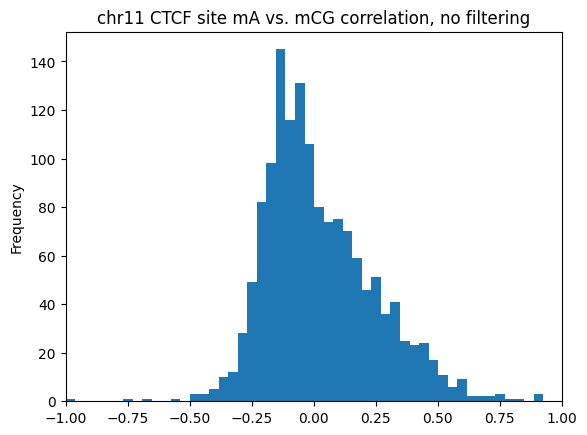

In [85]:
per_site_A_CG_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mA vs. mCG correlation, no filtering")
plt.show()

In [86]:
GC_CG_df = pd.merge(motif_read_region_mod_fracs["GCH,1"], motif_read_region_mod_fracs["WCG,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_GC", "_CG"])
# TODO: Understand the iloc indexing (something strange about multi-indexes) (also super annoyed df.corr only returns matrices)
per_site_GC_CG_correlations = GC_CG_df.groupby("window_spec")[["mod_frac_GC", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
per_site_GC_CG_correlations.index = per_site_GC_CG_correlations.index.droplevel(1)

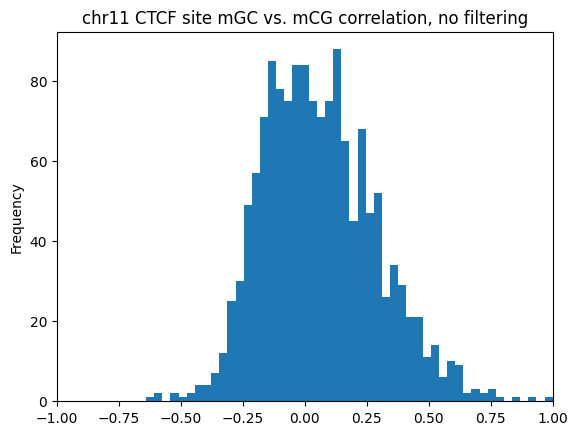

In [87]:
per_site_GC_CG_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mGC vs. mCG correlation, no filtering")
plt.show()

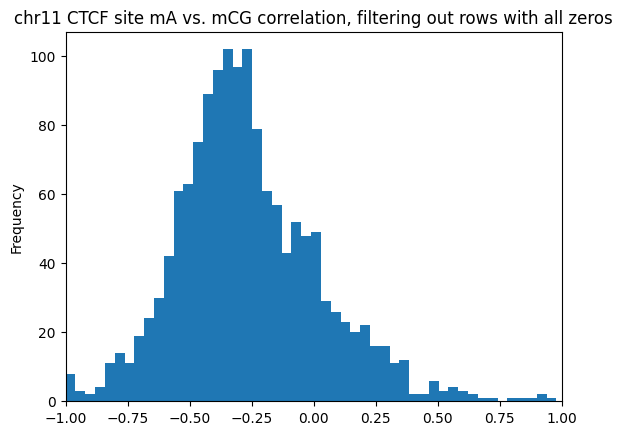

In [88]:
test = A_CG_df[~(A_CG_df[["mod_frac_A", "mod_frac_CG"]] == 0).all(axis="columns")]
test_correlations = test.groupby("window_spec")[["mod_frac_A", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
test_correlations.index = test_correlations.index.droplevel(1)

test_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mA vs. mCG correlation, filtering out rows with all zeros")
plt.show()

<Axes: ylabel='Frequency'>

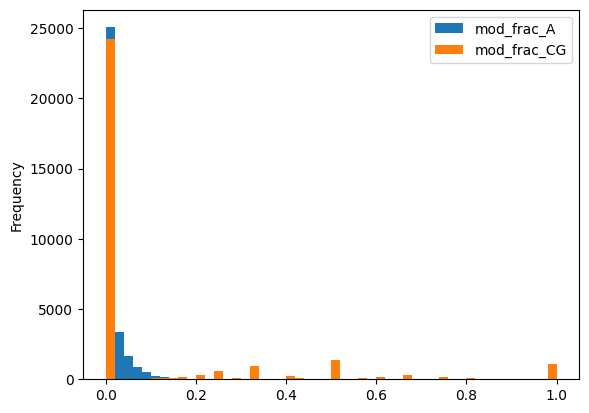

In [ ]:
A_CG_df[["mod_frac_A", "mod_frac_CG"]].plot.hist(bins=50)

# pre-processing of GpC control data

Note: `Basecalling mGpC mC was done automatically with an older version of the models (v4.3.0); continuing from there for the time being.` (so this should really be rebasecalled to be up to date)


```bash
DORADO_EXE=dorado-1.0.2-linux-x64/bin/dorado
EXPERIMENT_ID=experiment_id  # Desired name with which to label all output files
SEQ_KIT="SQK-LSK114"
BAM_FILE_BASENAME=$EXPERIMENT_ID.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3
OUTPUT_DIR=./  # Change if desired
REF_GENOME=chm13v2.0.fasta
FILTER_SCRIPT=dorado_summary_filter.py

$DORADO_EXE trim --sequencing-kit $SEQ_KIT $OUTPUT_DIR/$BAM_FILE_BASENAME.bam > $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.bam
$DORADO_EXE aligner $REF_GENOME $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.bam > $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.align.bam

$DORADO_EXE summary $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.align.bam > $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.align.dorado_summary.tsv
python $FILTER_SCRIPT $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.align.bam $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.align.dorado_summary.tsv -t 10

# Optional cleanup
rm $OUTPUT_DIR/$BAM_FILE_BASENAME.trim.bam
```